### 1.- Iniciamos descargando las librerias 📚 con las que trabajaremos el proyecto.

In [1]:
#Pandas: para el EDA y Limpieza.
#MySQL-Connector-Python: Para conectar con TiBD Cloud.
#Streamlit: Para el dasboard.
#Plotly: Para los graficos interactivos.
#Fastparquet: Para guardas el Dataset analítico de forma eficiente.

%pip install pandas mysql-connector-python streamlit plotly fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2.- TiDB Cloude ☁️

In [2]:
import mysql.connector

mysql_config = {
    "host": "gateway01.eu-central-1.prod.aws.tidbcloud.com",
    "port": 4000,
    "user": "2UKg9SGLbaBimU1.root",
    "password": "lFniGMm9rem5OvbV",
    "database": "proyecto_final",
    "ssl_disabled": False,
}

# Prueba de conexión rápida
try:
    conn = mysql.connector.connect(**mysql_config)
    print("¡Conexión exitosa a TiDB Cloud!")
    conn.close()
except Exception as e:
    print(f"Error al conectar: {e}")

¡Conexión exitosa a TiDB Cloud!


### 3.- Creación y modelado de tablas en SQL 📋

In [3]:
import pandas as pd

# 1. Cargamos los archivos (Esto define las variables y evita el error)
df_movies = pd.read_csv("tmdb_5000_movies.csv")
df_credits = pd.read_csv("tmdb_5000_credits.csv")

# 2. Mostramos la estructura de Movies
print("ESTRUCTURA DE MOVIES:")
df_movies.info()

print("\n" + "="*40 + "\n")

# 3. Mostramos la estructura de Credits
print("ESTRUCTURA DE CREDITS:")
df_credits.info()

ESTRUCTURA DE MOVIES:
<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status    

### 3.1.- Definimos las columnas a analizar ⚠️

In [4]:
# Filtrar movies
df_movies_final = df_movies[['id', 'title', 'budget', 'revenue', 'release_date', 'vote_average', 'popularity']].copy()

# Filtrar credits
df_credits_final = df_credits[['movie_id', 'title', 'cast', 'crew']].copy()

### 4.- Cargar los CSV en TiDB desde Python 💾

In [5]:
import pandas as pd
import mysql.connector
# Asumiendo que tus credenciales están en un archivo llamado credenciales.py
from credenciales import mysql_config 

# --- 1. DEFINIR EL HELPER DE CARGA (Tal cual pide tu tutor) ---
def cargar_csv_en_tabla(df, tabla, conn, batch=1000):
    """Inserta un DataFrame en una tabla de TiDB en lotes de `batch` filas."""
    cursor = conn.cursor()
    cols = ", ".join(df.columns)
    placeholders = ", ".join(["%s"] * len(df.columns))
    sql = f"INSERT INTO {tabla} ({cols}) VALUES ({placeholders})"

    # Limpiamos nulos de Pandas para que SQL los entienda
    filas = [tuple(None if pd.isna(v) else v for v in row)
             for row in df.itertuples(index=False, name=None)]

    for i in range(0, len(filas), batch):
        cursor.executemany(sql, filas[i:i+batch])
        conn.commit()
        print(f"  Tabla {tabla}: insertadas {min(i+batch, len(filas))}/{len(filas)}")
    cursor.close()

# --- 2. PREPARAR Y LIMPIAR DATOS ---
df_movies = pd.read_csv("tmdb_5000_movies.csv")
df_credits = pd.read_csv("tmdb_5000_credits.csv")

# Filtramos las columnas que decidimos conservar
df_movies_final = df_movies[['id', 'title', 'budget', 'revenue', 'release_date', 'vote_average', 'popularity']].copy()
# IMPORTANTE: Convertir fecha como pide el tutor para evitar errores
df_movies_final['release_date'] = pd.to_datetime(df_movies_final['release_date']).dt.date

df_credits_final = df_credits[['movie_id', 'title', 'cast', 'crew']].copy()
# Renombramos para que coincida con tu CREATE TABLE de SQL (image_376b81.png)
df_credits_final.columns = ['movie_id', 'title', 'cast_json', 'crew_json']

# --- 3. EJECUTAR LA CONEXIÓN Y CARGA ---
try:
    conn = mysql.connector.connect(**mysql_config)
    print("Conexión exitosa. Iniciando carga...")

    # ORDEN: Primero el padre (movies), luego la hija (credits)
    cargar_csv_en_tabla(df_movies_final, "movies", conn)
    cargar_csv_en_tabla(df_credits_final, "credits", conn)

    conn.close()
    print("¡Proceso finalizado con éxito!")
except Exception as e:
    print(f"Error durante la carga: {e}")

Conexión exitosa. Iniciando carga...
Error durante la carga: 1062 (23000): Duplicate entry '?' for key 'movies.PRIMARY'


### 5.- Extraer el DataSet analítico.

In [6]:
import pandas as pd
import mysql.connector
from credenciales import mysql_config

# 1. Establecer la conexión
conn = mysql.connector.connect(**mysql_config)

# 2. Definir la consulta SQL (JOIN)
# Seleccionamos las columnas importantes de ambas tablas
query = """
SELECT 
    m.id, 
    m.title, 
    m.budget, 
    m.revenue, 
    m.release_date, 
    m.vote_average, 
    m.popularity,
    c.cast_json, 
    c.crew_json
FROM movies m
JOIN credits c ON m.id = c.movie_id
"""

# 3. Extraer los datos hacia un nuevo DataFrame
df_analitico = pd.read_sql(query, conn)

# 4. Cerrar la conexión (Buena práctica)
conn.close()

# 5. Visualizar el resultado
print("Dataset analítico generado con éxito.")
display(df_analitico.head())

C:\Users\rever\AppData\Local\Temp\ipykernel_18400\3261751295.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_analitico = pd.read_sql(query, conn)


Dataset analítico generado con éxito.


,id,title,budget,revenue,release_date,vote_average,popularity,cast_json,crew_json
0,5,Four Rooms,4000000,4300000,1995-12-09,6.5,22.8762,"[{""cast_id"": 42, ""character"": ""Ted the Bellhop...","[{""credit_id"": ""52fe420dc3a36847f800012d"", ""de..."
1,11,Star Wars,11000000,775398007,1977-05-25,8.1,126.3937,"[{""cast_id"": 3, ""character"": ""Luke Skywalker"",...","[{""credit_id"": ""52fe420dc3a36847f8000437"", ""de..."
2,12,Finding Nemo,94000000,940335536,2003-05-30,7.6,85.6888,"[{""cast_id"": 8, ""character"": ""Marlin (voice)"",...","[{""credit_id"": ""52fe420ec3a36847f80006b1"", ""de..."
3,13,Forrest Gump,55000000,677945399,1994-07-06,8.2,138.1333,"[{""cast_id"": 7, ""character"": ""Forrest Gump"", ""...","[{""credit_id"": ""52fe420ec3a36847f800076b"", ""de..."
4,14,American Beauty,15000000,356296601,1999-09-15,7.9,80.8786,"[{""cast_id"": 6, ""character"": ""Lester Burnham"",...","[{""credit_id"": ""52fe420ec3a36847f8000809"", ""de..."


### 5.1.- Guardamos el DataSet localmente con .parquet

In [7]:
# Guardar en formato Parquet (es más rápido y ligero que CSV)
df_analitico.to_parquet("dataset_analitico.parquet")
print("Archivo 'dataset_analitico.parquet' guardado localmente.")

Archivo 'dataset_analitico.parquet' guardado localmente.


### 6.- Limpieza y procesamiento 🧹

In [8]:
import ast

# 1. Función para sacar solo los nombres de los actores
def limpiar_cast(json_str):
    lista = ast.literal_eval(json_str) # Convierte el texto en lista real
    nombres = [actor['name'] for actor in lista]
    return ", ".join(nombres[:3]) # Solo nos quedamos con los 3 primeros actores

# 2. Función para sacar el nombre del Director
def obtener_director(json_str):
    lista = ast.literal_eval(json_str)
    for persona in lista:
        if persona['job'] == 'Director':
            return persona['name']
    return "Desconocido"

# Aplicamos los cambios al DataFrame
df_analitico['cast_json'] = df_analitico['cast_json'].apply(limpiar_cast)
df_analitico['crew_json'] = df_analitico['crew_json'].apply(obtener_director)

# Cambiamos los nombres de las columnas para que queden más bonitos
df_analitico = df_analitico.rename(columns={'cast_json': 'actores', 'crew_json': 'director'})

display(df_analitico.head())


,id,title,budget,revenue,release_date,vote_average,popularity,actores,director
0,5,Four Rooms,4000000,4300000,1995-12-09,6.5,22.8762,"Tim Roth, Antonio Banderas, Jennifer Beals",Allison Anders
1,11,Star Wars,11000000,775398007,1977-05-25,8.1,126.3937,"Mark Hamill, Harrison Ford, Carrie Fisher",George Lucas
2,12,Finding Nemo,94000000,940335536,2003-05-30,7.6,85.6888,"Albert Brooks, Ellen DeGeneres, Alexander Gould",Andrew Stanton
3,13,Forrest Gump,55000000,677945399,1994-07-06,8.2,138.1333,"Tom Hanks, Robin Wright, Gary Sinise",Robert Zemeckis
4,14,American Beauty,15000000,356296601,1999-09-15,7.9,80.8786,"Kevin Spacey, Annette Bening, Thora Birch",Sam Mendes


### 6.1.- Tipos correctos y nulos.

In [9]:
# Ver cuántos nulos hay en cada columna
print("NULOS POR COLUMNA:")
print(df_analitico.isna().sum())

# Si hay nulos en 'budget' o 'revenue', los llenamos con 0 para poder hacer cálculos
df_analitico['budget'] = df_analitico['budget'].fillna(0)
df_analitico['revenue'] = df_analitico['revenue'].fillna(0)

NULOS POR COLUMNA:
id              0
title           0
budget          0
revenue         0
release_date    1
vote_average    0
popularity      0
actores         0
director        0
dtype: int64


### 6.1.1.- Eliminamos nulo

In [10]:
# 1. Eliminar la fila que tiene la fecha nula
df_analitico = df_analitico.dropna(subset=['release_date'])

# 2. Verificar que ya no hay nulos
print("NULOS RESTANTES:")
print(df_analitico.isnull().sum())

# 3. Guardar el progreso como el dataset definitivo para el EDA
df_analitico.to_parquet("dataset_final_limpio.parquet")
print("\n¡Dataset guardado y sin nulos.")

NULOS RESTANTES:
id              0
title           0
budget          0
revenue         0
release_date    0
vote_average    0
popularity      0
actores         0
director        0
dtype: int64

¡Dataset guardado y sin nulos.


### 6.2.- Duplicados

In [11]:
# Contar duplicados
duplicados = df_analitico.duplicated().sum()
print(f"Películas duplicadas encontradas: {duplicados}")

# Si hay, los borramos
if duplicados > 0:
    df_analitico = df_analitico.drop_duplicates()

Películas duplicadas encontradas: 0


### 6.3.- Outliers 📈

In [12]:
# Filtrar películas con presupuesto o recaudación negativa (errores de datos)
df_analitico = df_analitico[df_analitico['budget'] >= 0]
df_analitico = df_analitico[df_analitico['revenue'] >= 0]

# Filtrar fechas imposibles (ej. antes de 1900 si las hay)
df_analitico = df_analitico[df_analitico['release_date'] > pd.to_datetime('1900-01-01').date()]

### 6.4.-Preprocesamiento 📖

In [14]:
# Definimos el diccionario de traducción
columnas_espanol = {
    'id': 'id_pelicula',
    'title': 'titulo',
    'budget': 'presupuesto',
    'revenue': 'ingresos',
    'release_date': 'fecha_estreno',
    'vote_average': 'puntuacion_media',
    'popularity': 'popularidad',
    'actores': 'reparto',
    'director': 'director',
    'año': 'anio_estreno',
    'mes': 'mes_estreno',
    'ganancia': 'beneficio',
    'roi': 'retorno_inversion'
}

# Renombramos las columnas en el DataFrame
df_analitico = df_analitico.rename(columns=columnas_espanol)

# Mostramos cómo ha quedado
print("Columnas traducidas correctamente:")
display(df_analitico.head())

Columnas traducidas correctamente:


,id_pelicula,titulo,presupuesto,ingresos,fecha_estreno,puntuacion_media,popularidad,reparto,director
0,5,Four Rooms,4000000,4300000,1995-12-09,6.5,22.8762,"Tim Roth, Antonio Banderas, Jennifer Beals",Allison Anders
1,11,Star Wars,11000000,775398007,1977-05-25,8.1,126.3937,"Mark Hamill, Harrison Ford, Carrie Fisher",George Lucas
2,12,Finding Nemo,94000000,940335536,2003-05-30,7.6,85.6888,"Albert Brooks, Ellen DeGeneres, Alexander Gould",Andrew Stanton
3,13,Forrest Gump,55000000,677945399,1994-07-06,8.2,138.1333,"Tom Hanks, Robin Wright, Gary Sinise",Robert Zemeckis
4,14,American Beauty,15000000,356296601,1999-09-15,7.9,80.8786,"Kevin Spacey, Annette Bening, Thora Birch",Sam Mendes


### 7.- EDA 🔍🔎

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuración para que los gráficos se vean bonitos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Configura el formato de visualización para floats
pd.options.display.float_format = '{:,.2f}'.format

### 7.1.- Descripción general.

In [20]:
# Resumen rápido del dataset traducido
print(f"Contamos con un dataset de {df_analitico.shape[0]} películas.")
print(f"Periodo analizado: desde {df_analitico['fecha_estreno'].min()} hasta {df_analitico['fecha_estreno'].max()}")
display(df_analitico[['presupuesto', 'ingresos', 'puntuacion_media']].describe())

Contamos con un dataset de 4802 películas.
Periodo analizado: desde 1916-09-04 hasta 2017-02-03


,presupuesto,ingresos,puntuacion_media
count,"4,802.00","4,802.00","4,802.00"
mean,"29,051,088.41","82,277,769.15",6.09
std,"40,724,474.30","162,869,733.01",1.19
min,0.00,0.00,0.00
25%,"800,000.00",0.00,5.60
50%,"15,000,000.00","19,174,985.00",6.20
75%,"40,000,000.00","92,919,195.00",6.80
max,"380,000,000.00","2,787,965,087.00",10.00


### 7.2 Análisis Univariante.

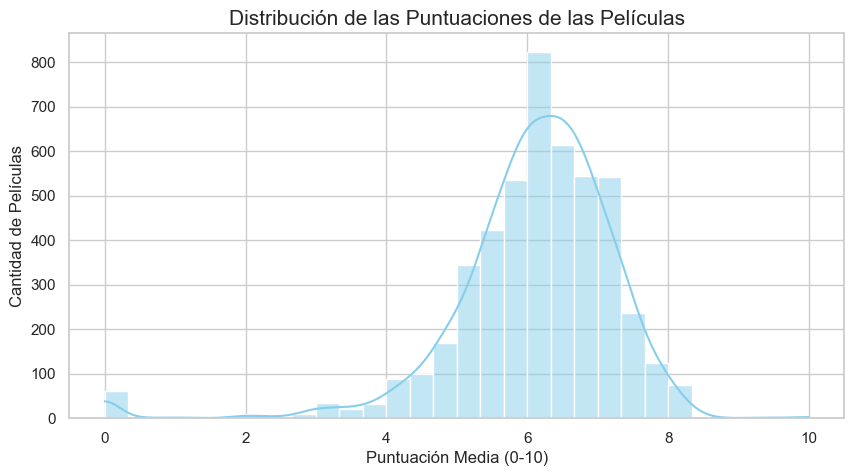

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df_analitico['puntuacion_media'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de las Puntuaciones de las Películas', fontsize=15)
plt.xlabel('Puntuación Media (0-10)')
plt.ylabel('Cantidad de Películas')
plt.show()

# Insight escrito: "La mayoría de las películas se concentran entre 5.5 y 7.0 puntos. 
# Es raro encontrar películas con menos de 4 o más de 8.5."

### 7.3.- Análisis Bivariante.

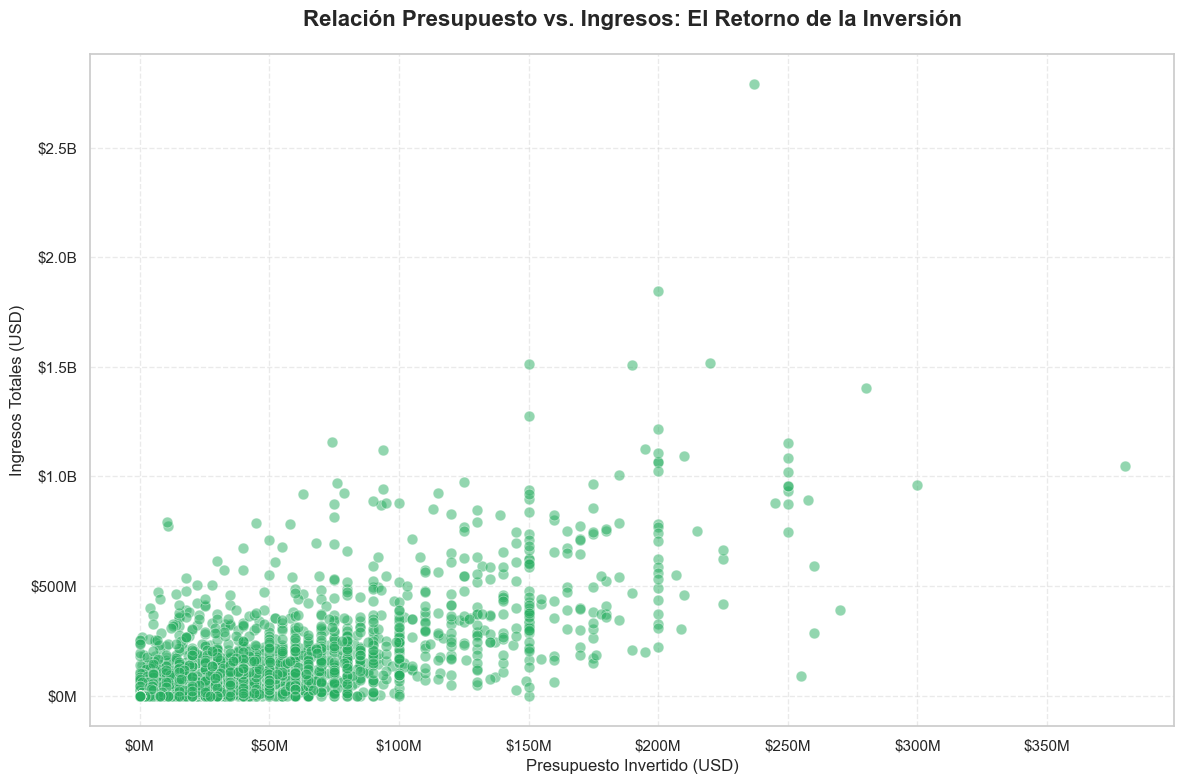

Hallazgo: Se confirma una correlación positiva. Las películas que superan los $200M de presupuesto
rara vez fallan en recaudar al menos el doble, aunque los grandes éxitos ('outliers') 
están concentrados en la parte superior del gráfico.


In [44]:
import matplotlib.ticker as ticker

# 1. Configuración de estilo y tamaño
plt.figure(figsize=(12, 8))

# 2. Scatter plot mejorado
# Usamos 's' para el tamaño de punto y 'edgecolor' para que se distingan si se solapan
sns.scatterplot(data=df_analitico, x='presupuesto', y='ingresos', 
                alpha=0.5, color='#27ae60', s=60, edgecolor='w', linewidth=0.5)


# Formateador para el eje X (Presupuesto en Millones)
def millones_x(x, pos):
    return f'${x*1e-6:.0f}M'

# Formateador para el eje Y (Ingresos en Millones o Billones)
def millones_y(x, pos):
    if x >= 1e9:
        return f'${x*1e-9:.1f}B'
    return f'${x*1e-6:.0f}M'

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(millones_x))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(millones_y))

# 3. Títulos e información detallada
plt.title('Relación Presupuesto vs. Ingresos: El Retorno de la Inversión', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Presupuesto Invertido (USD)', fontsize=12)
plt.ylabel('Ingresos Totales (USD)', fontsize=12)

# Añadimos una línea de referencia (opcional, ayuda a ver la tendencia)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Insight actualizado
print("Hallazgo: Se confirma una correlación positiva. Las películas que superan los $200M de presupuesto")
print("rara vez fallan en recaudar al menos el doble, aunque los grandes éxitos ('outliers') ")
print("están concentrados en la parte superior del gráfico.")

### 7.4.- Hallazgos.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargamos el dataset final
df = pd.read_parquet("dataset_final_limpio.parquet")

#### 7.4.1 Evolución temporal de los ingresos.

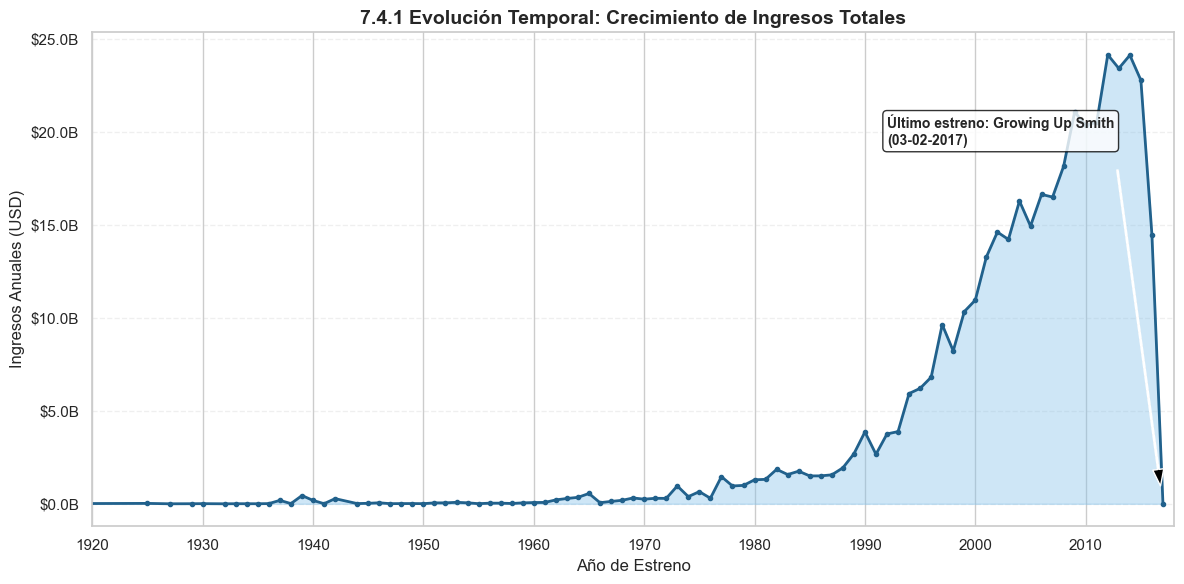

Hallazgo: El dataset finaliza el 03-02-2017 con la película: 'Growing Up Smith'


In [45]:
import matplotlib.ticker as ticker

# 1. Preparación de los datos (Esto corrige el error de "not defined")
col_fecha = 'fecha_estreno' if 'fecha_estreno' in df.columns else 'release_date'
df[col_fecha] = pd.to_datetime(df[col_fecha])
df['anio_estreno'] = df[col_fecha].dt.year

# Calculamos la variable que faltaba
evolucion_ingresos = df.groupby('anio_estreno')['ingresos' if 'ingresos' in df.columns else 'revenue'].sum()

# 2. Identificar última fecha para la anotación
ultima_fecha = df[col_fecha].max()
fecha_formateada = ultima_fecha.strftime('%d-%m-%Y')
nombre_ultima = df.loc[df[col_fecha] == ultima_fecha, 'titulo' if 'titulo' in df.columns else 'title'].iloc[0]

# 3. Configurar el gráfico
plt.figure(figsize=(12, 6))

# Dibujamos el área y la línea
plt.fill_between(evolucion_ingresos.index, evolucion_ingresos.values, color='#85C1E9', alpha=0.4)
plt.plot(evolucion_ingresos.index, evolucion_ingresos.values, color='#21618C', linewidth=2, marker='o', markersize=3)

# --- ANOTACIÓN DE LA ÚLTIMA FECHA ---
plt.annotate(f'Último estreno: {nombre_ultima}\n({fecha_formateada})', 
             xy=(ultima_fecha.year, evolucion_ingresos.get(ultima_fecha.year, 0)),
             xytext=(ultima_fecha.year - 25, evolucion_ingresos.max() * 0.8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

# --- FORMATEO ---
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'${x*1e-9:.1f}B'))
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))

plt.title('7.4.1 Evolución Temporal: Crecimiento de Ingresos Totales', fontsize=14, fontweight='bold')
plt.xlabel('Año de Estreno')
plt.ylabel('Ingresos Anuales (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xlim(1920, ultima_fecha.year + 1)

plt.tight_layout()
plt.show()

print(f"Hallazgo: El dataset finaliza el {fecha_formateada} con la película: '{nombre_ultima}'")